In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
import numpy as np
from scipy.signal import convolve2d, correlate2d
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift

import sys
sys.path.append('..')
from functions.Functions import *
from functions.utils import create_plots
import time


# 1. Difference Operators

In [3]:
def dx_mask(h=1, pad = 5):
    dx = np.zeros((pad, pad))
    f = np.array([1,0,-1])/(2*h)
    f = np.pad(f, 0 if pad == 3 else 1)
    dx[pad//2 ,:] = f
    return dx

def dy_mask(h=1, pad = 5):
    return dx_mask(h=h, pad = pad).T

def dxx_mask(h=1, pad = 5):
    dxx = np.zeros((pad, pad))
    f = np.array([1, -2, 1])/(h**2)
    f = np.pad(f, 0 if pad == 3 else 1)
    dxx[pad //2 ,:] = f
    return dxx

def dyy_mask(h=1, pad = 5):
    return dxx_mask(h=h, pad = pad).T

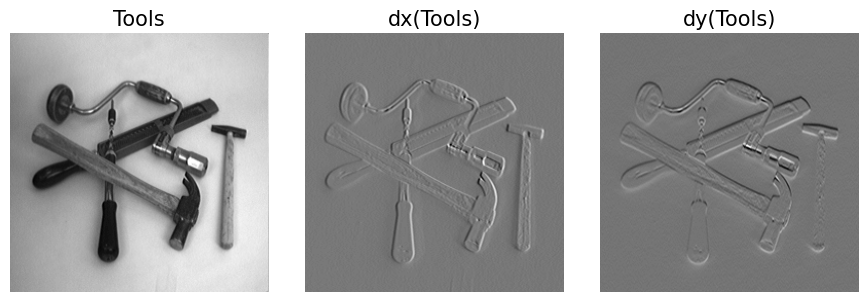

In [4]:
dx = dx_mask()
dy = dy_mask()

tools = np.load("../images/Images-npy/few256.npy")
dxtools = convolve2d(tools, dx, 'valid')
dytools = convolve2d(tools, dy, 'valid')
                     
create_plots(1, 3, [tools, dxtools, dytools],
              col_list = ['Tools', 'dx(Tools)', 'dy(Tools)'])

# 2. Point–wise thresholding of gradient magnitudes

In [5]:
def gaussfft(pic, t):
    
    ## Gaussian kernel
    Nx, Ny = pic.shape
    x = np.arange(0, Ny)
    y = np.arange(0, Nx)
    X, Y = np.meshgrid(x, y)
    X = X - Ny/2
    Y = Y - Nx/2

    gaussian_kernel = np.exp(-(X**2 + Y**2)/(2*t))
    gaussian_kernel /= np.sum(gaussian_kernel)

    ## Move origin of filter to corner (0,0)
    gaussian_kernel = np.fft.ifftshift(gaussian_kernel)

    ## Compute convolution
    F = fft2(pic)
    FG = fft2(gaussian_kernel)
    return np.real(ifft2(F * FG)) 

In [6]:
def Lv(inpic, dxmask, dymask, shape = 'same', sigma=1):
    if sigma is not None:
        inpic = gaussfft(inpic, sigma)
    Lx = convolve2d(inpic, dxmask, shape)
    Ly = convolve2d(inpic, dymask, shape)
    return np.sqrt(Lx**2 + Ly**2)

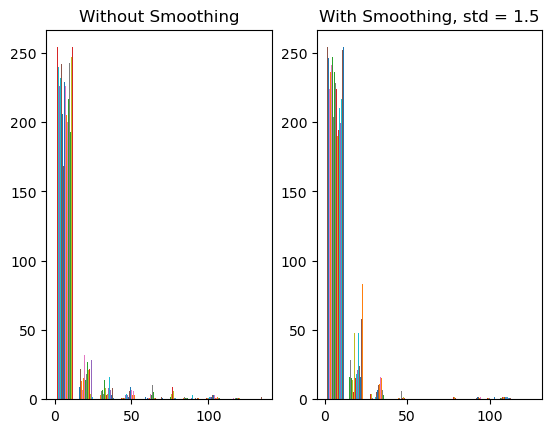

In [7]:
plt.subplot(1,2,1)
gradmagntools = Lv(tools, dx, dy, sigma=None)
plt.title('Without Smoothing')
plt.hist(gradmagntools)

plt.subplot(1,2,2)
plt.title('With Smoothing, std = 1.5')
gradmagntools = Lv(tools, dx, dy, sigma=1.5)
plt.hist(gradmagntools)

plt.show()




In [8]:
house = np.load("../images/Images-npy/godthem256.npy")

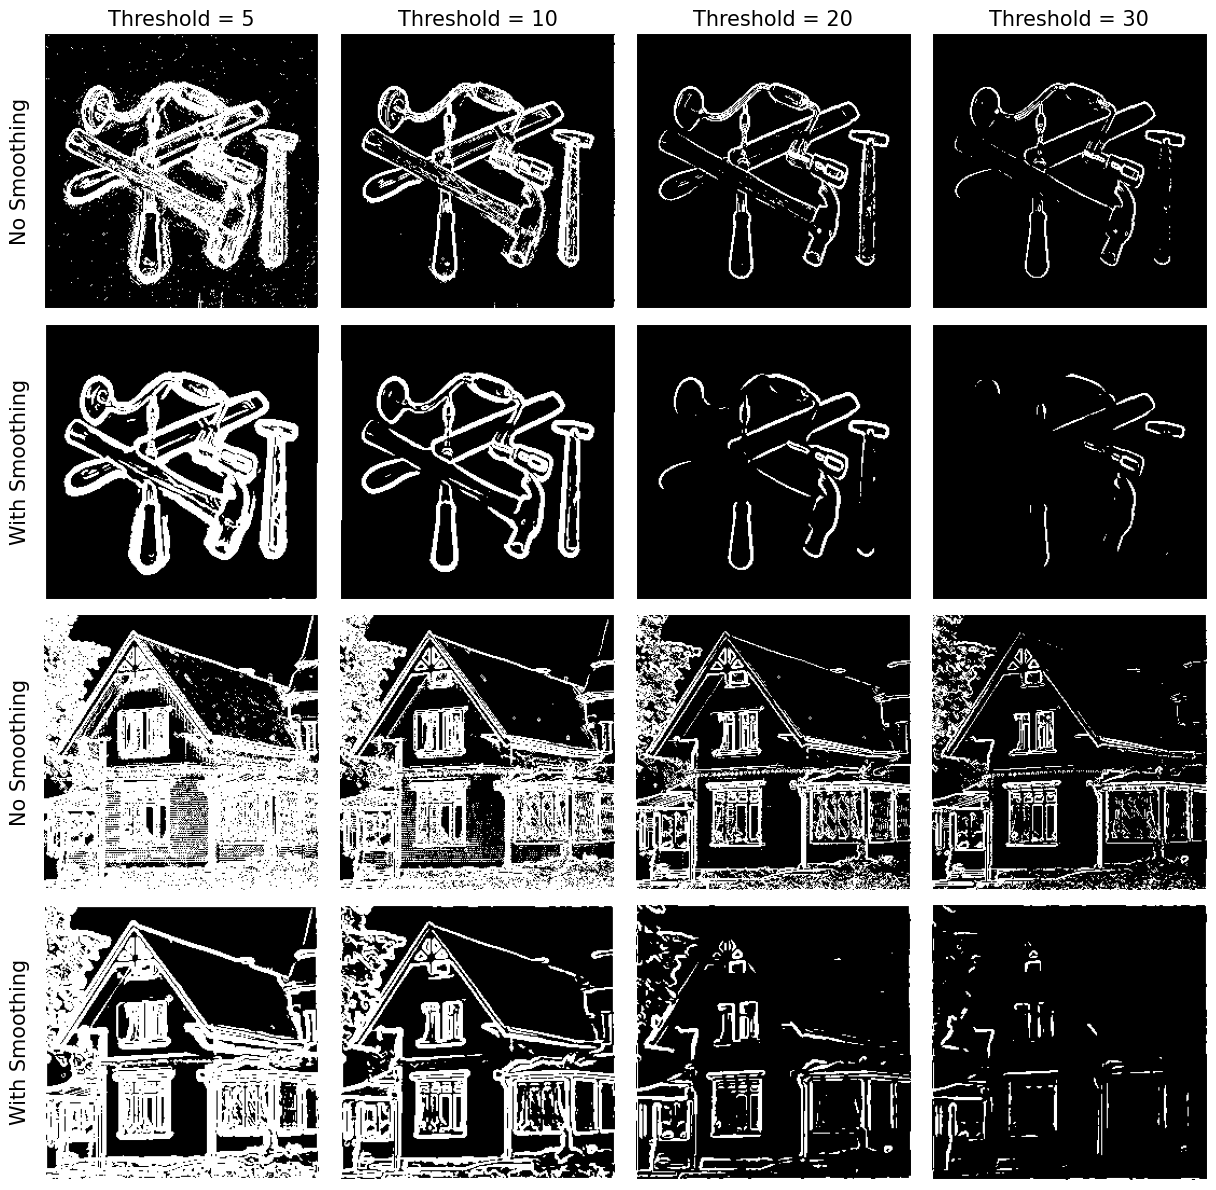

In [9]:
th_list = [5, 10, 20, 30]

sigma = None
gradmagntools = Lv(tools, dx, dy, sigma=sigma)
gradmagnhouse = Lv(house, dx, dy, sigma=sigma)

img_list_tools1 = [(gradmagntools > th).astype(int) for th in th_list]
img_list_house1 = [(gradmagnhouse > th).astype(int) for th in th_list]

sigma = 1.5
gradmagntools = Lv(tools, dx, dy, sigma=sigma)
gradmagnhouse = Lv(house, dx, dy, sigma=sigma)

img_list_tools2 = [(gradmagntools > th).astype(int) for th in th_list]
img_list_house2 = [(gradmagnhouse > th).astype(int) for th in th_list]




create_plots(4, 4, [*img_list_tools1, *img_list_tools2, *img_list_house1, *img_list_house2],
              col_list = ['Threshold = ' + str(i) for i in th_list],
              row_list=['No Smoothing', 'With Smoothing', 'No Smoothing', 'With Smoothing'])



# 4. Computing differential geometry descriptors

In [10]:
def d_filters(pad=5, order=3):
    dx = dx_mask(1, pad)
    dy = dy_mask(1, pad)

    dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = [None] * 7

    if order >= 2:
        dxx = dxx_mask(1, pad)
        dyy = dyy_mask(1, pad)
        dxy = convolve2d(dx, dy, 'same')
    
    
    if order >= 3:
        dxxx = convolve2d(dx, dxx, 'same')
        dyyy = convolve2d(dy, dyy, 'same')
        dxxy = convolve2d(dxx, dy, 'same')
        dxyy = convolve2d(dx, dyy, 'same')
    
    return dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy

def Lvvtilde(inpic, sigma=1, kernel_size=5):
    if sigma is not None:
        L = gaussfft(inpic, sigma)
    else:
        L = inpic.copy
    
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(kernel_size, 3)
        
    Lx = convolve2d(L, dx, 'same')
    Ly = convolve2d(L, dy, 'same')
    Lxx = convolve2d(L, dxx, 'same')
    Lyy = convolve2d(L, dyy, 'same')

    Lxy = convolve2d(L, dxy, 'same')

    Lvv = Lx**2 * Lxx + 2 * Lx * Ly * Lxy + Ly**2 * Lyy

    return Lvv

def Lvvvtilde(inpic, sigma=1, kernel_size=5):
    if sigma is not None:
        L = gaussfft(inpic, sigma)
    else:
        L = inpic.copy()
    
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(kernel_size, 3)
        
    Lx = convolve2d(L, dx, 'same')
    Ly = convolve2d(L, dy, 'same')

    Lxxx = convolve2d(L, dxxx, 'same')
    Lyyy = convolve2d(L, dyyy, 'same')
    Lxyy = convolve2d(L, dxyy, 'same')
    Lxxy = convolve2d(L, dxxy, 'same')

    Lvvv = Lx**3 * Lxxx + 3 * Lx**2 * Ly * Lxxy +  3 * Lx * Ly**2 * Lxyy + Ly**3 * Lyyy

    return Lvvv

In [11]:
def test1(var, n, pad=5):
    '''
    # Test 1: dx(x^n) = nx^(n-1)

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    u_num = convolve2d(f, dx, 'valid')
    u_analytic = n * var**(n-1)

    #return u_num, u_analytic
    assert np.allclose(u_num, u_analytic, 1e-6), "Test not passed!"

def test2(var, n, pad=5):
    '''
    # Test 2: dx^n(x^n) = n!

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    if n == 1:
        dd = dx
    elif n == 2: 
        dd = dxx
    elif n == 3:
        dd = dxxx

    u_num = convolve2d(f, dd, 'valid')
    u_analytic = math.factorial(n) * np.ones(shape=u_num.shape)

    assert np.allclose(u_num, u_analytic, 1e-6), "Test not passed!"

def test3(var, n, pad=5):
    '''
     # Test 3: dx^(n+k)(x^n) = 0

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    if n == 1:
        dd = dxx
    elif n == 2: 
        dd = dxxx
    u_num = convolve2d(f, dd, 'valid')
    
    assert np.allclose(u_num, np.zeros(shape=u_num.shape)), "Test not passed!"

def test4(var, n, pad=5, axis='x'):
    '''
     # Test 4: dx^n(y^k) = 0

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)
    if axis == 'y':
        if n == 1:
            dd = dx
        elif n == 2: 
            dd = dxx
        elif n == 3:
            dd = dxxx
    elif axis == 'x':
        if n == 1:
            dd = dy
        elif n == 2: 
            dd = dyy
        elif n == 3:
            dd = dyyy
    
    u_num = convolve2d(f, dd, 'valid')
    assert np.allclose(u_num, np.zeros(shape=u_num.shape)), "Test not passed!"

[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))

# test1(x, n=1)
# test1(x, n=2)
# test1(x, n=3)

test2(x, n=1)
test2(x, n=2)
test2(x, n=3)

test3(x, n=1)
test3(x, n=2)

test4(x, n=1, axis='x')
test4(x, n=2, axis='x')
test4(x, n=3, axis='x')
test4(y, n=1, axis='y')
test4(y, n=2, axis='y')
test4(y, n=3, axis='y')
    


In [12]:
def tests(x, y):
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=5)
    f1 = convolve2d(x**3, dxxx, 'valid')
    assert np.allclose(f1, 6*np.ones(shape=f1.shape)), "Test not passed!"

    f2 = convolve2d(x**3, dxx, 'valid')
    analytical = 6*x

    extra_cols = len(analytical) - len(f2)
    analytical = analytical[extra_cols//2:extra_cols//2 + len(f2), extra_cols//2:extra_cols//2 + len(f2)]

    assert np.allclose(f2, analytical), "Test not passed!"

    f3 = convolve2d(x**2*y, dxxy, 'valid')
    assert np.allclose(f3, 2*np.ones(shape=f3.shape)), "Test not passed!"

[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
tests(x, y)

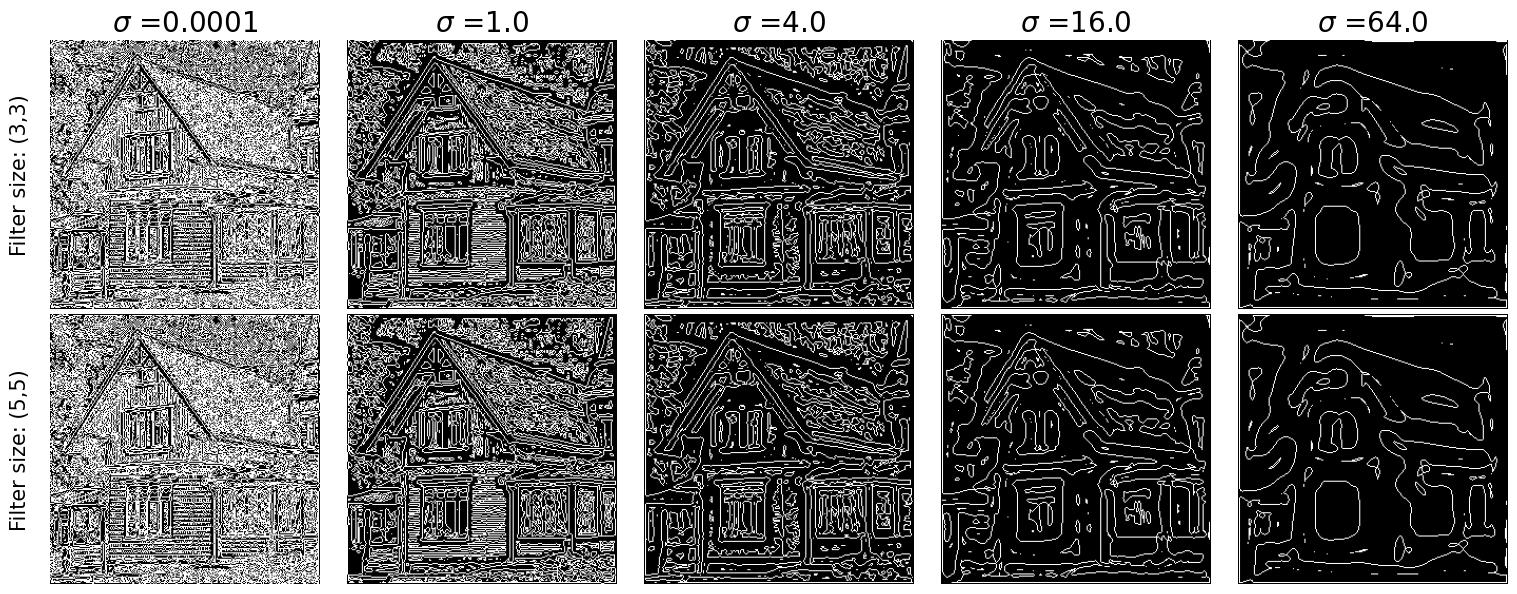

In [114]:
sigma_list = [0.0001, 1.0, 4.0, 16.0, 64.0]
img_list3 = [contour(Lvvtilde(house, sigma=s, kernel_size=3)) for s in sigma_list]
img_list5 = [contour(Lvvtilde(house, sigma=s, kernel_size=5)) for s in sigma_list]

create_plots(2,len(sigma_list),
             image_list=[*img_list3, *img_list5], 
             col_list=[r'$\sigma$ =' + str(s) for s in sigma_list], 
             row_list=['Filter size: (3,3)', 'Filter size: (5,5)'],
             title_fontsize=20)


In [144]:
def detect_edges(img, sigma, threshold=None, kernel_size=5, out='curves', return_gradmagn=False):
    dx, dy, *_ = d_filters(pad=5)
    
    Lv_magnitude = Lv(img, dx, dy, shape = 'same', sigma=sigma)
    Lvv = Lvvtilde(img, sigma=sigma, kernel_size=kernel_size)
    if out == 'Lvvmask':
        return Lvv

    Lvvv = Lvvvtilde(img, sigma=sigma, kernel_size=kernel_size)
    mask1 = Lvvv < 0
    if out == 'Lvvvmask':
        return mask1
    
    if out == 'curves':
        curves = zerocrosscurves(Lvv, mask1)
        
        if threshold is not None:
            mask2 = Lv_magnitude > threshold
            curves = thresholdcurves(curves, mask2)
        if return_gradmagn:
            return curves, Lv_magnitude
        else:
            return curves
    

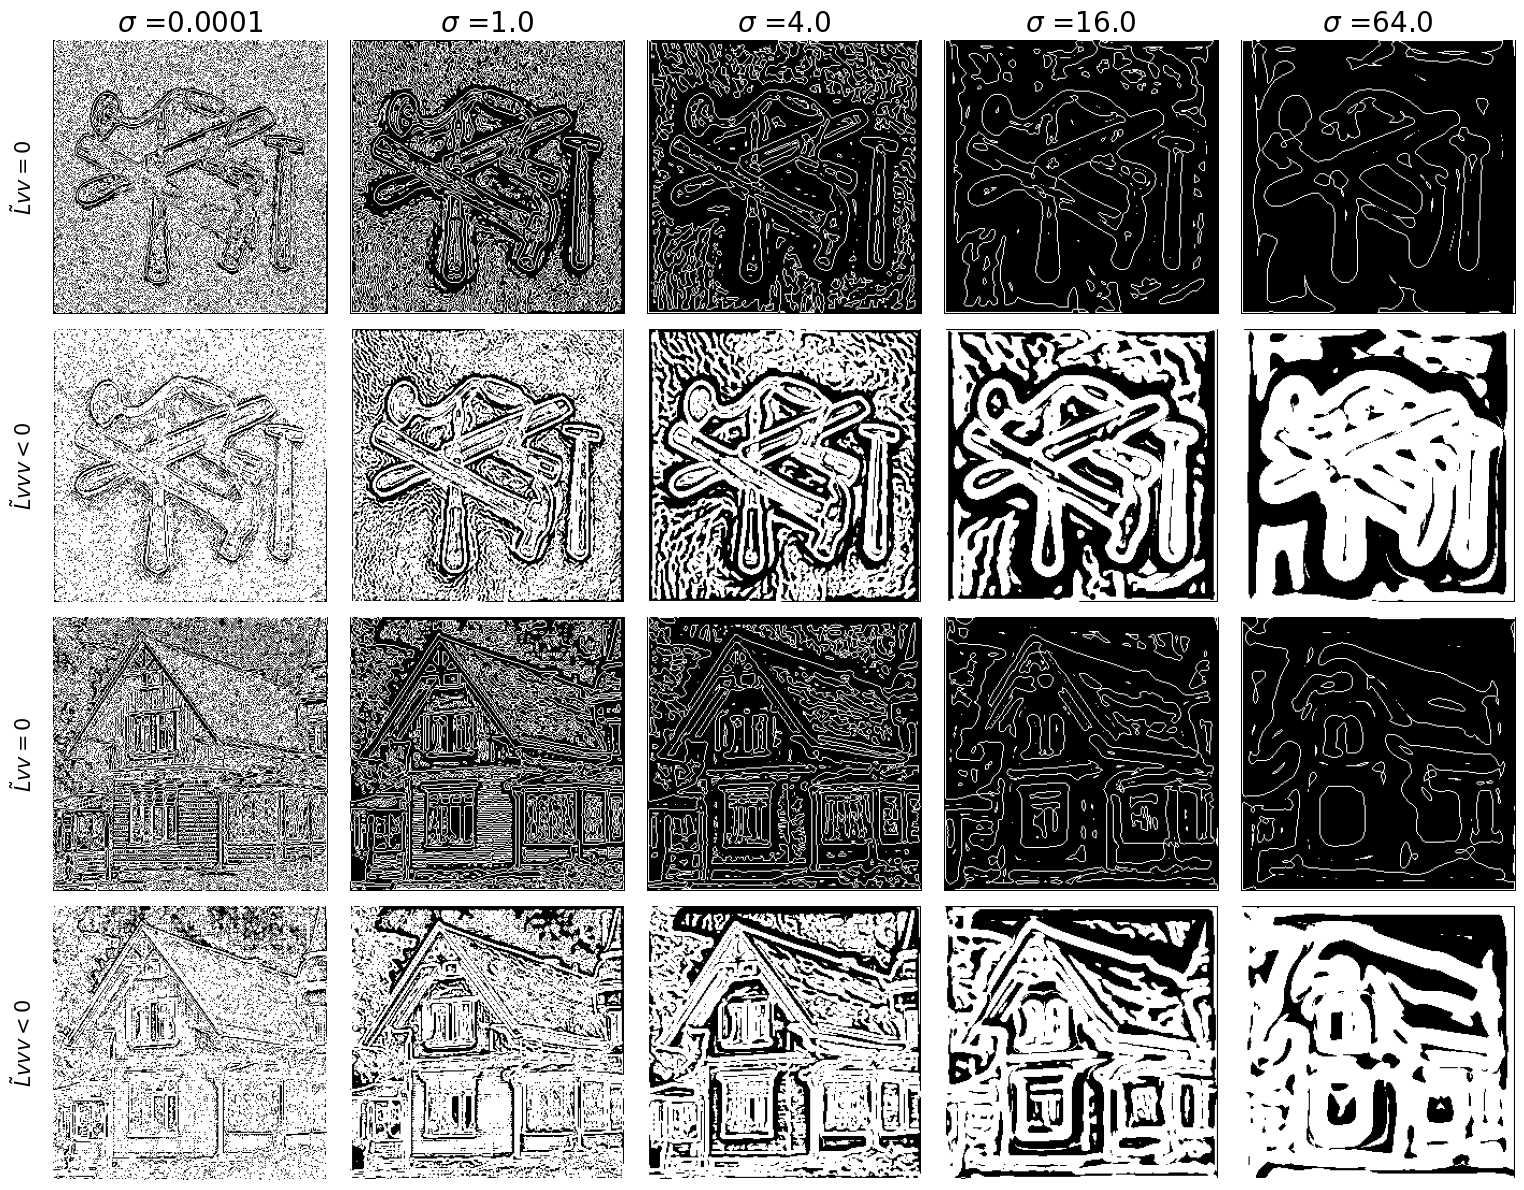

In [139]:
sigma_list = [0.0001, 1.0, 4.0, 16.0, 64.0]
img_tools1 = [contour(detect_edges(tools, sigma=s, kernel_size=5, out='Lvvmask')) for s in sigma_list]
img_tools2 = [(detect_edges(tools, sigma=s, kernel_size=5, out='Lvvvmask')).astype(int) for s in sigma_list]
img_house1 = [contour(detect_edges(house, sigma=s, kernel_size=5, out='Lvvmask')) for s in sigma_list]
img_house2 = [(detect_edges(house, sigma=s, kernel_size=5, out='Lvvvmask')).astype(int) for s in sigma_list]

create_plots(4,len(sigma_list),
             image_list=[*img_tools1, *img_tools2, *img_house1, *img_house2], 
             col_list=[r'$\sigma$ =' + str(s) for s in sigma_list], 
             row_list=[r'$\tilde{L}vv = 0$', r'$\tilde{L}vvv < 0$', 
                       r'$\tilde{L}vv = 0$',r'$\tilde{L}vvv < 0$'],
             title_fontsize=20)


# 5. Extraction of edge segments

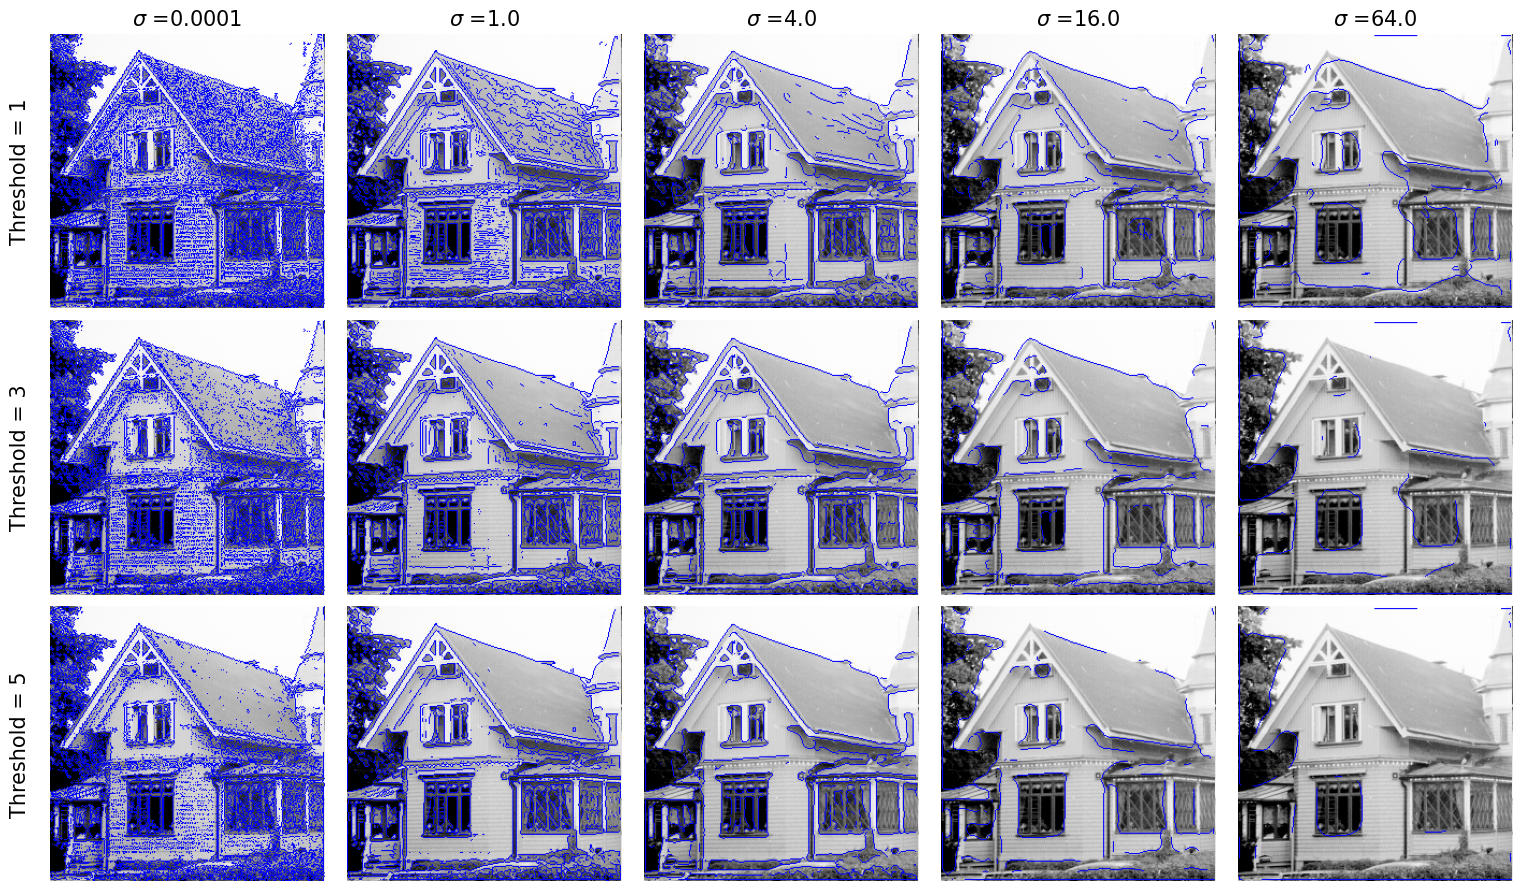

In [16]:
sigma_list = [0.0001, 1.0, 4.0, 16.0, 64.0]
threshold_list = [1,3,5]
image_list = []

img = house

for th in threshold_list:
    for s in sigma_list:
        edgecurves = detect_edges(img, sigma=s, threshold=th)
        image_list.append(overlaycurves(img, edgecurves))

create_plots(len(threshold_list),len(sigma_list),
             image_list=image_list,
             col_list=[r'$\sigma$ =' + str(s) for s in sigma_list],
             row_list=['Threshold = '  + str(th) for th in threshold_list],
             gray=False)

[]

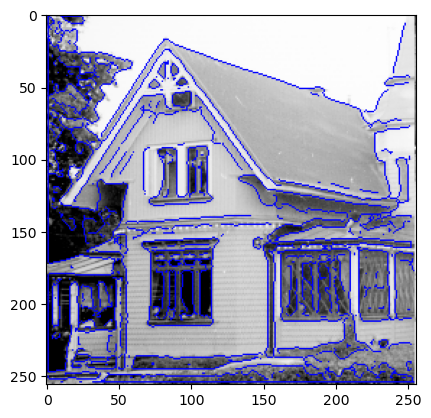

In [17]:
edgecurves = detect_edges(house, sigma=4, threshold=3)
plt.imshow(overlaycurves(house, edgecurves))
plt.plot()

# 6. Hough transform

In [ ]:
def plot_edges(img, linepar, acc, ntheta, nrho, verbose=0, plotlog=False):
    H, W = img.shape

    if verbose == 0:
        return 

    # Only Hough space
    elif verbose == 1: 
        plt.figure(figsize=(5,5))
        if plotlog:
            showgrey(np.log(1 + acc) + 1e-10, display=False)
            plt.title('Log Hough Space')
        else:
            showgrey(acc, display=False)
            plt.title('Hough Space')

        # Make the axes square
        plt.gca().set_aspect(
            (acc.shape[1]/acc.shape[0]),  # scale y vs x to be square
            adjustable='box'
        )

        plt.xticks([0, (ntheta-1) //2, ntheta-1], ["0", "π/2", "π"])
        plt.yticks([0, nrho-1], ["-R", "+R"])
        plt.show()
    
    # Only edges
    elif verbose == 2:
        showgrey(img, display=False)
        for (rho, theta) in linepar:
            x0 = rho * np.cos(theta) + W/2
            y0 = rho * np.sin(theta) + H/2

            l = max(W,H)
            #l = 60
            dx = -np.sin(theta) * l
            dy = np.cos(theta) * l

            plt.plot([x0 - dx, x0, x0 + dx],
                     [y0 - dy, y0, y0 + dy],
                       'r-')
        plt.title('Hough space')
        plt.xticks([], [])
        plt.yticks([], [])

    
    # Hough space + Image with edges overlaid
    elif verbose == 3:
        fig, axes = plt.subplots(1, 2, figsize=(10,5))

        # Left
        plt.sca(axes[0])
        if plotlog:
            showgrey(np.log(1 + acc) + 1e-10, display=False)
            plt.title('Log Hough Space')
        else:
            showgrey(acc, display=False)
            plt.title('Hough Space')

        # Ensure square display
        axes[0].set_aspect((acc.shape[1]/acc.shape[0]), adjustable='box')
        plt.xticks([0, (ntheta-1) //2, ntheta-1], ["0", "π/2", "π"])
        plt.yticks([0, nrho-1], ["-R", "+R"])

        # Right
        plt.sca(axes[1])
        showgrey(img, display=False)
        for (rho, theta) in linepar:
            x0 = rho * np.cos(theta) + W/2
            y0 = rho * np.sin(theta) + H/2

            l = max(W,H)
            #l = 60
            dx = -np.sin(theta) * l
            dy = np.cos(theta) * l

            plt.plot([x0 - dx, x0, x0 + dx],
                     [y0 - dy, y0, y0 + dy],
                       'r-')
        plt.title('')

        axes[1].set_aspect(1, adjustable='box')  # image is square on screen

        plt.tight_layout()
        plt.show()
    


In [187]:
def houghline(img, sigma, gradmagnthreshold, nrho, ntheta, nlines, 
              smooth=False, verbose=0, plotlog=False, accumulator='ones'):

    curves, gradmagn = detect_edges(img, sigma, threshold=gradmagnthreshold, 
                                    kernel_size=5, out='curves', return_gradmagn=True)
    
    # Size of image
    H, W = img.shape
    R = np.sqrt((W/2)**2 + (H/2)**2)
    
    # Define accumulator matrix
    acc = np.zeros((nrho, ntheta))
    theta = np.linspace(0, np.pi, ntheta)
    length = 2*R / nrho

    # Transform cartesian -> radial and recenter
    (Y, X) = curves
    gradmagn = gradmagn[Y, X]

    Yc = Y - H/2
    Xc = X - W/2
    r = np.outer(Xc, np.cos(theta)) + np.outer(Yc, np.sin(theta))

    # Map each r point to the rho index in the acc matrix
    rho_index = np.floor((r + R) / length).astype(int) # Rho mapped to acc boxes
    rho_index = np.clip(rho_index, 0, nrho-1)          # Clip index to [0, rho-1]
    
    # Define accumulator
    if accumulator == 'ones':
        weights = np.ones_like(gradmagn)
        
    elif accumulator == 'linear':
        weights = gradmagn/(gradmagn.max())

    elif accumulator == 'sigmoid':
        weights = gradmagn/(gradmagn.max())
        weights = 1 / (1 + np.exp(-3*weights))

    # For each (rho index, theta index) add the number of values in r in that cell
    for col in range(ntheta):
        rho_indices_in_theta_box = rho_index[:, col]       # Rho indices with same Theta index
        np.add.at(acc, (rho_indices_in_theta_box, col), weights) # Add +1 for each Rho indices with same Theta index
            # Same as acc[rho_indices_for_theta, col] += 1 but accounts for repeated indices

    if smooth:
        acc = gaussfft(acc, 0.1)

    # Extract maximum values of acc
    pos, value, _ = locmax8(acc)
    indexvector = np.argsort(value)[-nlines:]
    pos = pos[indexvector]

    # Obtain indices of lines in acc matrix
    linepar = []
    for line in range(nlines):
        theta_acc_id = pos[line, 0]
        rho_acc_id = pos[line, 1]
        
        rho = rho_acc_id * length - R
        th = theta[theta_acc_id]
        linepar.append((rho, th))
    plot_edges(img=img, linepar=linepar, acc=acc,
               ntheta=ntheta, nrho=nrho, verbose=verbose, plotlog=plotlog)

    return linepar, acc
    

In [147]:
test1 = np.load("../images/Images-npy/triangle128.npy")
test2 = np.load("../images/Images-npy/houghtest256.npy")

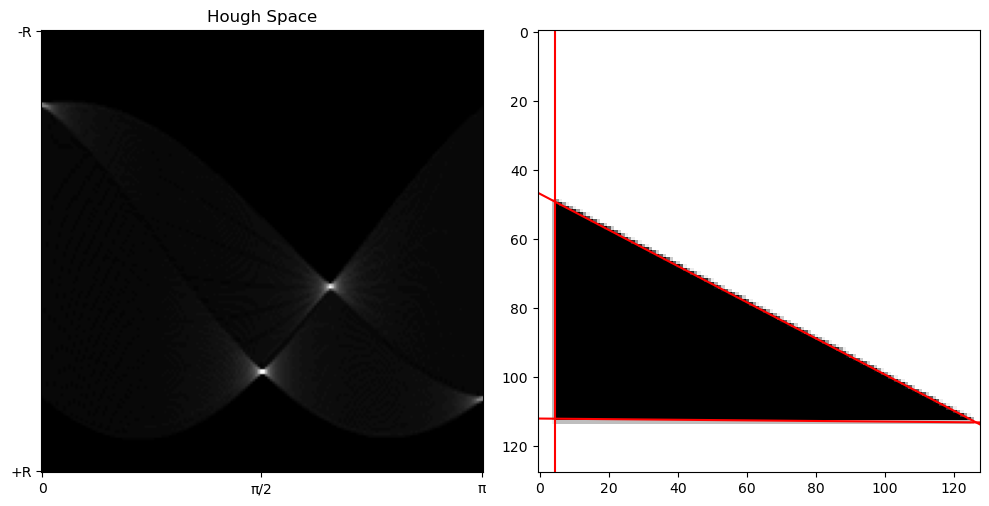

In [150]:
img = test1
sigma = 4
gradmagnthreshold = 1

H, W = img.shape
R = np.sqrt((W/2)**2 + (H/2)**2)

nrho, nthta = int(2*R), 180

nlines = 3

linepar, acc = houghline(img, sigma, gradmagnthreshold, nrho, nthta, nlines, smooth=True, verbose=3, plotlog=False)


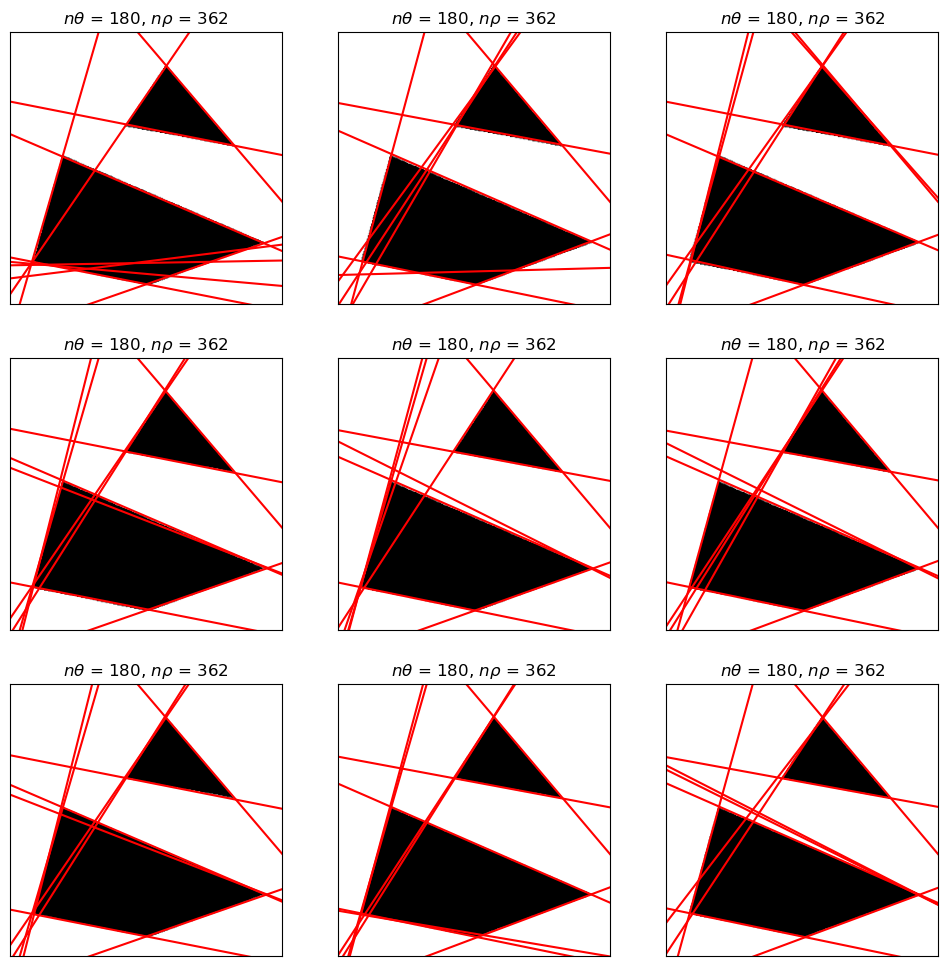

In [200]:
img = test2
sigma = 4
gradmagnthreshold = 1

H, W = img.shape
R = np.sqrt((W/2)**2 + (H/2)**2)

nlines = 10

nrho, ntheta = int(2*R), 180

i = 1
scale = [0.5, 1, 1.5]
plt.figure(figsize=(12, 12))
for nr in scale:
    for nt in scale:
        plt.subplot(3,3,i)
        start = time.time()
        _, _  = houghline(img, sigma, gradmagnthreshold, int(nr*nrho), int(nt*ntheta), nlines, smooth=True, verbose=2)
        end = time.time()
        plt.title(r'$n\theta$ = ' + str(ntheta) + r', $n\rho$ = ' +str(nrho))
        #print(end - start)
        i += 1


### 6.2 Choice of accumulator incrementation function

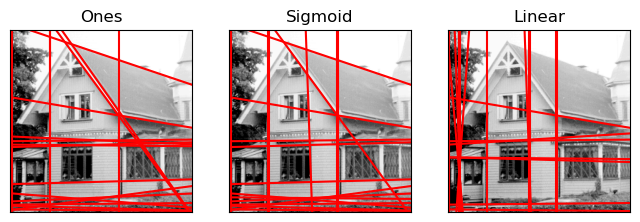

In [204]:
img = house
sigma = 4
gradmagnthreshold = 5

H, W = img.shape
R = np.sqrt((W/2)**2 + (H/2)**2)

nrho, nthta = int(2*R), 180

nlines = 20

plt.figure(figsize=(8, 8))
plt.subplot(1,3,1)

linepar, acc = houghline(img, sigma, gradmagnthreshold, nrho, nthta, nlines, 
                         smooth=True, verbose=2, plotlog=False,
                         accumulator='ones')
plt.title('Ones')

plt.subplot(1,3,2)
linepar, acc = houghline(img, sigma, gradmagnthreshold, nrho, nthta, nlines, 
                         smooth=True, verbose=2, plotlog=False,
                         accumulator='sigmoid')
plt.title('Sigmoid')

plt.subplot(1,3,3)
linepar, acc = houghline(img, sigma, gradmagnthreshold, nrho, nthta, nlines, 
                         smooth=True, verbose=2, plotlog=False,
                         accumulator='linear')
plt.title('Linear')

plt.show()

